Load credentials

In [ ]:

try:
    from dotenv import load_dotenv, find_dotenv
    import os

    if not load_dotenv():
        load_dotenv(find_dotenv())


    HOST = os.getenv("HOST")
    if HOST is None:
        print("Variables not found. Check .env")

    else:
        PORT = os.getenv("PORT")
        USERNAME = os.getenv("USERNAME")
        PASSWORD = os.getenv("PASSWORD")
        DATABASE = os.getenv("DATABASE")
        



except:
    print("Cant load env")

In [6]:
import mysql.connector
from mysql.connector import Error

connection = mysql.connector.connect(
    host=HOST,
    port=PORT,
    user=USERNAME,
    password=PASSWORD,
    database=DATABASE
)

cursor = connection.cursor()
if connection.is_connected():
    print("Connected")

else:
    print("Not connected, check server or credentials")

Connected


In [59]:
cursor.execute("SHOW TABLES;")
tables = [row[0] for row in cursor.fetchall()]
print(f"Found {len(tables)} tables:")
for t in tables:
    print(" -", t)

Found 4 tables:
 - catalogue
 - landcover
 - terrain
 - training_table


In [60]:
schema = {}

for table in tables:
    cursor.execute(f"""
        SELECT COLUMN_NAME, DATA_TYPE, IS_NULLABLE, COLUMN_KEY, COLUMN_DEFAULT
        FROM INFORMATION_SCHEMA.COLUMNS
        WHERE TABLE_SCHEMA = DATABASE()
        AND TABLE_NAME = %s
        ORDER BY ORDINAL_POSITION;
    """, (table,))
    
    columns = cursor.fetchall()
    schema[table] = columns

    print(f"\nTable: {table}")
    for col_name, data_type, nullable, key, default in columns:
        key_marker = f" [{key}]" if key else ""
        print(f"  - {col_name} ({data_type}){key_marker}")


Table: catalogue
  - collection_id (varchar) [PRI]
  - title (varchar)
  - constellation (varchar)
  - instruments (varchar)
  - processing_level (varchar)
  - gsd_min_m (decimal)
  - gsd_max_m (decimal)
  - n_bands (smallint)
  - band_names (text)
  - temporal_start (datetime)
  - temporal_end (datetime)
  - bbox (varchar)
  - license (varchar)
  - doi (varchar)
  - providers (varchar)
  - keywords (varchar)

Table: landcover
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - class_code (tinyint)
  - class_name (varchar)

Table: terrain
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - elevation_m (decimal)

Table: training_table
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - elevation_m (decimal)
  - slope_deg (decimal)
  - land_cover_code (tinyint)
  - land_cover_class (varchar)
  - is_built_up (tinyint)


In [61]:
import pandas as pd

In [62]:
rows = []
for table, columns in schema.items():
    for col_name, data_type, nullable, key, default in columns:
        rows.append({
            "table": table,
            "column": col_name,
            "type": data_type,
            "nullable": nullable,
            "key": key,
            "default": default
        })

df = pd.DataFrame(rows)
df

,table,column,type,nullable,key,default
0,catalogue,collection_id,varchar,NO,PRI,NaN
1,catalogue,title,varchar,NO,,NaN
2,catalogue,constellation,varchar,YES,,NULL
3,catalogue,instruments,varchar,YES,,NULL
4,catalogue,processing_level,varchar,YES,,NULL
5,catalogue,gsd_min_m,decimal,YES,,NULL
6,catalogue,gsd_max_m,decimal,YES,,NULL
7,catalogue,n_bands,smallint,NO,,NaN
8,catalogue,band_names,text,YES,,NULL
9,catalogue,temporal_start,datetime,NO,,NaN


In [63]:
query = "SELECT * FROM  catalogue"
df = pd.read_sql(query, connection)
df

/tmp/ipykernel_128606/3475825759.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,collection_id,title,constellation,instruments,processing_level,gsd_min_m,gsd_max_m,n_bands,band_names,temporal_start,temporal_end,bbox,license,doi,providers,keywords
0,ccm-optical,Copernicus Contributing Missions Optical,alos;beijing;dmc;geosat;worldview;formosat;geo...,aeiss;avnir-2;awf;bgi;dem;dove;gis;hirais;hr;h...,L1;L2,0.5,66.0,0,,1998-01-19 14:44:39,NaT,"-83.711914,-35.5704748260475,65.787712,80.984856",other,,ESA;CloudFerro,Copernicus;ESA;EU;Imagery;Optical;Reflectance;...
1,ccm-sar,Copernicus Contributing Missions SAR,cosmo-skymed;iceye;paz;radarsat;terrasar-x,sar;x-sar;xsar1,,0.0,0.0,0,,2011-05-31 06:26:33,NaT,"-179.95546,-81.05,179.96101,143.99498",other,,ESA;CloudFerro,Copernicus;ESA;EU;Imagery;SAR;Radar;Satellite;...
2,clms_ba_global_300m_daily_v3_cog,CLMS Burnt Area (BA) Global 300m daily V3 (COG),sentinel-3,olci;slstr,L3,300.0,300.0,1,dob_nrt,2023-07-01 00:00:00,2025-11-01,"-179.9999999,-59.9985119,179.9985119,80.0014881",other,10.2909/9c0519f9-d2c2-4469-a9e1-2222d37c33d6,CloudFerro;European Environment Agency;Europea...,Copernicus;CLMS;BA;Burnt Area;fire disturbance...
3,clms_ba_global_300m_daily_v3_nc,CLMS Burnt Area (BA) Global 300m daily V3 (Net...,sentinel-3,olci;slstr,L3,300.0,300.0,1,day_of_burn,2023-07-01 00:00:00,2025-11-01,"-179.9999999,-59.9985119,179.9985119,80.0014881",other,10.2909/9c0519f9-d2c2-4469-a9e1-2222d37c33d6,CloudFerro;European Environment Agency;Europea...,Copernicus;CLMS;BA;Burnt Area;fire disturbance...
4,clms_ba_global_300m_daily_v4_cog,CLMS Burnt Area (BA) Global 300m daily V4 (COG),sentinel-3,olci;slstr,L3,300.0,300.0,4,cp_nrt;bf_nrt;dob_nrt;lfp_nrt,2024-12-01 00:00:00,NaT,"-179.9999999,-59.9985119,179.9985119,80.0014881",other,10.2909/bfd77180-7d7c-4c1c-b193-1489f735d5f1,CloudFerro;European Environment Agency;Europea...,Copernicus;CLMS;BA;Burnt Area;fire disturbance...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,sentinel-6-p4-1b-ntc,Sentinel-6 P4 Level 1B Non Time Critical (NTC),sentinel-6,p4,L1,20000.0,20000.0,2,;,2021-12-16 17:38:58,NaT,"-180,-90,180,90",other,,EUMETSAT;European Commission;CloudFerro,Copernicus;Sentinel;EU;ESA;EUMETSAT;Satellite;...
414,sentinel-6-p4-1b-stc,Sentinel-6 P4 Level 1B Short Time Critical (STC),sentinel-6,p4,L1,20000.0,20000.0,2,;,2021-10-09 10:13:44,NaT,"-180,-90,180,90",other,,EUMETSAT;European Commission;CloudFerro,Copernicus;Sentinel;EU;ESA;EUMETSAT;Satellite;...
415,sentinel-6-p4-2-nrt,Sentinel-6 P4 Level 2 Near Real-Time (NRT),sentinel-6,p4,L2,20000.0,20000.0,2,;,2021-10-09 05:15:37,NaT,"-180,-90,180,90",other,,EUMETSAT;European Commission;CloudFerro,Copernicus;Sentinel;EU;ESA;EUMETSAT;Satellite;...
416,sentinel-6-p4-2-ntc,Sentinel-6 P4 Level 2 Non Time Critical (NTC),sentinel-6,p4,L2,20000.0,20000.0,2,;,2021-10-30 00:19:22,NaT,"-180,-90,180,90",other,,EUMETSAT;European Commission;CloudFerro,Copernicus;Sentinel;EU;ESA;EUMETSAT;Satellite;...


In [64]:
query = "SELECT * FROM  terrain"
df = pd.read_sql(query, connection)
df

/tmp/ipykernel_128606/2886241580.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,longitude,latitude,elevation_m
0,1,12.500208,55.699861,36.19
1,2,12.500625,55.699861,36.39
2,3,12.501042,55.699861,34.77
3,4,12.501458,55.699861,36.19
4,5,12.501875,55.699861,38.23
...,...,...,...,...
34555,34556,12.578125,55.650139,3.69
34556,34557,12.578542,55.650139,3.46
34557,34558,12.578958,55.650139,4.00
34558,34559,12.579375,55.650139,6.22


All the tables can be accessed through "dfs"

In [69]:
dfs = {}

for table_name, table_info in schema.items():
    query = f"SELECT * FROM {table_name}"
    dfs[table_name] = pd.read_sql(query, connection)

/tmp/ipykernel_128606/3869150288.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[table_name] = pd.read_sql(query, connection)


In [72]:
dfs["training_table"]

,id,longitude,latitude,elevation_m,slope_deg,land_cover_code,land_cover_class,is_built_up
0,1179632,12.500042,55.699958,36.19,0.68,10,Tree cover,0
1,1179633,12.500125,55.699958,36.19,0.68,10,Tree cover,0
2,1179634,12.500208,55.699958,36.19,0.68,10,Tree cover,0
3,1179635,12.500292,55.699958,36.19,0.68,50,Built-up,1
4,1179636,12.500375,55.699958,36.19,0.68,50,Built-up,1
...,...,...,...,...,...,...,...,...
575995,1755627,12.579625,55.650042,5.64,7.27,10,Tree cover,0
575996,1755628,12.579708,55.650042,5.64,7.27,10,Tree cover,0
575997,1755629,12.579792,55.650042,5.64,7.27,10,Tree cover,0
575998,1755630,12.579875,55.650042,5.64,7.27,10,Tree cover,0


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


In [75]:
def pivot_to_grid(df, value_col):
    """
    Convert long-format (lon, lat, value) rows into a 2D array
    suitable for imshow, using unique sorted lon/lat as the axes.
    """
    lons = np.sort(df["longitude"].unique())
    lats = np.sort(df["latitude"].unique())[::-1]  # north at top
 
    lon_idx = {v: i for i, v in enumerate(lons)}
    lat_idx = {v: i for i, v in enumerate(lats)}
 
    grid = np.full((len(lats), len(lons)), np.nan)
 
    rows = df["latitude"].map(lat_idx).values
    cols = df["longitude"].map(lon_idx).values
    grid[rows, cols] = df[value_col].values
 
    extent = [lons.min(), lons.max(), lats.min(), lats.max()]
    return grid, extent
 


In [ ]:
def plot_land_cover(df):
    grid, extent = pivot_to_grid(df, "land_cover_code")
 
    # Map ESA WorldCover-style codes to colors/labels (extend as needed)
    code_to_label = dict(zip(df["land_cover_code"], df["land_cover_class"]))
    codes = sorted(code_to_label.keys())
    labels = [code_to_label[c] for c in codes]
 
    cmap = ListedColormap(plt.cm.tab20.colors[: len(codes)])
    bounds = codes + [codes[-1] + 1]
    norm = BoundaryNorm(bounds, cmap.N)
 
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(grid, extent=extent, cmap=cmap, norm=norm, origin="upper")
 
    cbar = fig.colorbar(im, ax=ax, ticks=[c + 0.5 for c in codes])
    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Land cover class")
 
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Land Cover Grid")
    plt.tight_layout()
    plt.show()
 


In [ ]:
def plot_built_up(df):
    grid, extent = pivot_to_grid(df, "is_built_up")
 
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(grid, extent=extent, cmap="Greys", origin="upper")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Built-up Areas (1 = built-up)")
    fig.colorbar(im, ax=ax, label="is_built_up")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_elevation(df):
    grid, extent = pivot_to_grid(df, "elevation_m")
 
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(grid, extent=extent, cmap="terrain", origin="upper")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Elevation (m)")
    fig.colorbar(im, ax=ax, label="Elevation (m)")
    plt.tight_layout()
    plt.show()


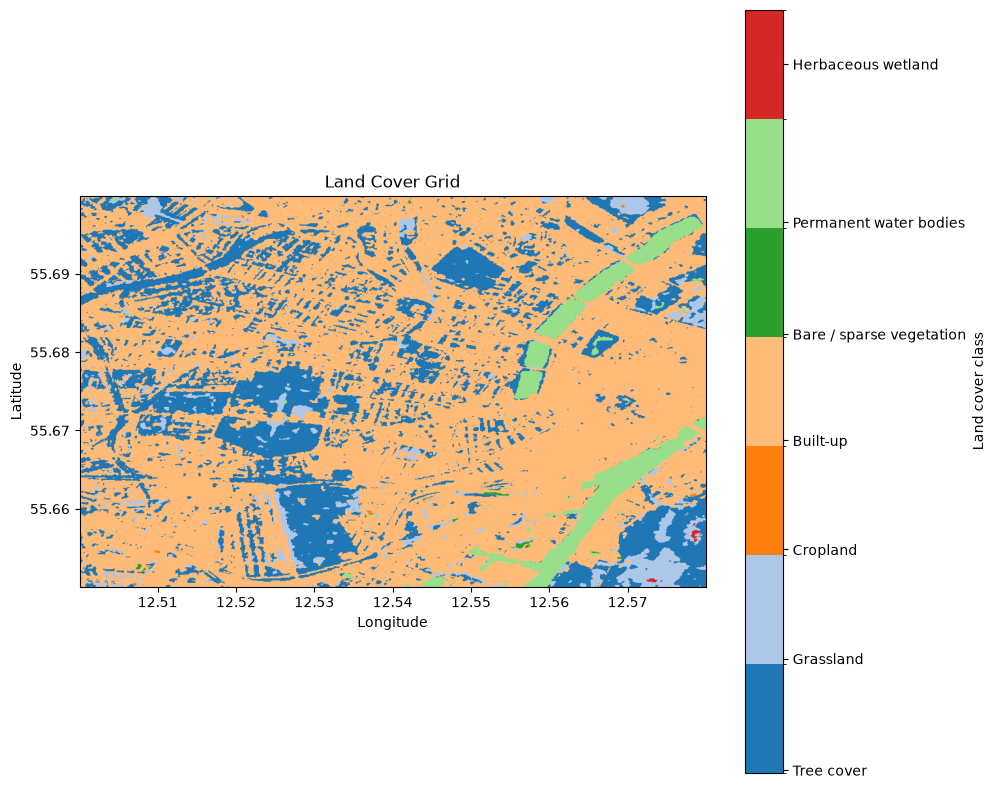

In [79]:
plot_land_cover(dfs["training_table"])

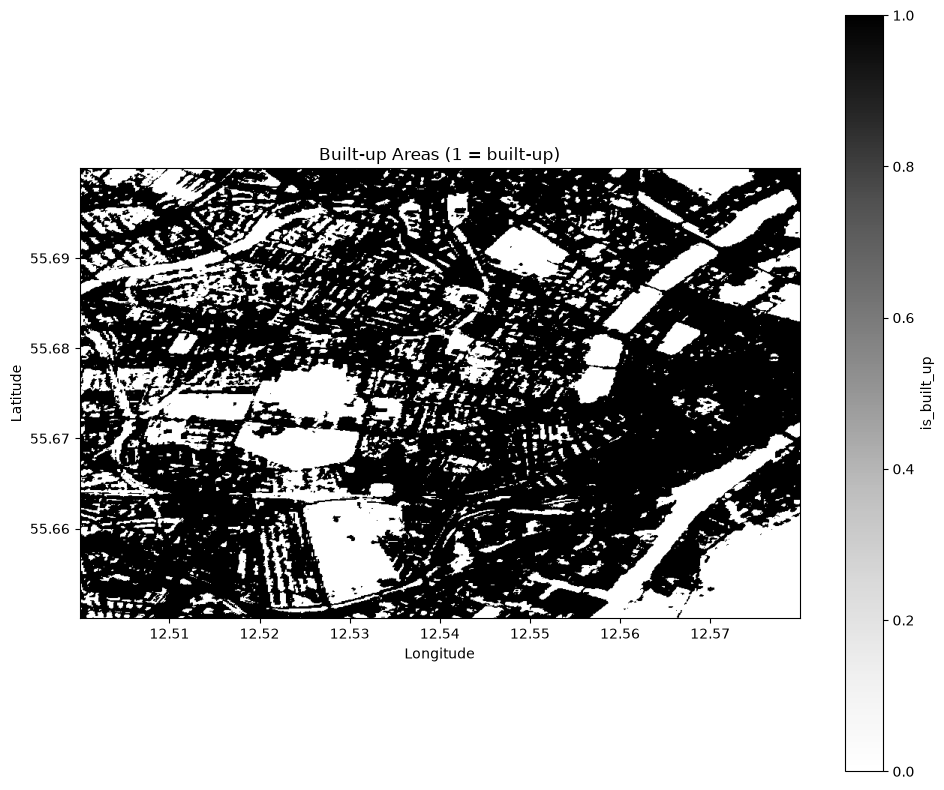

In [80]:
plot_built_up(dfs["training_table"])

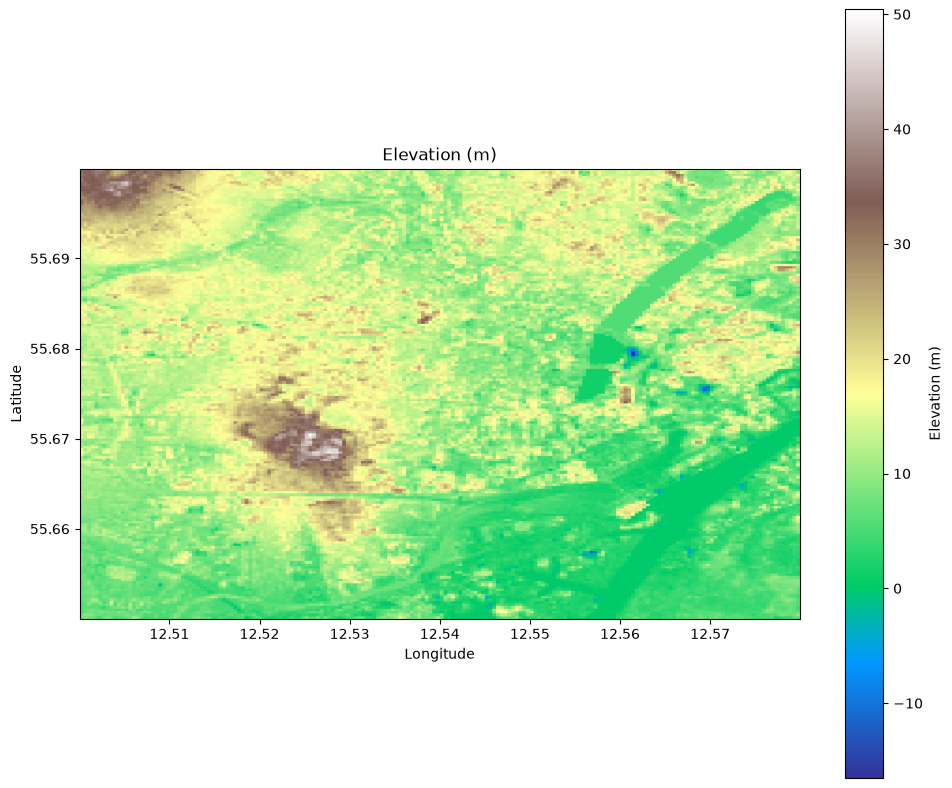

In [83]:
plot_elevation(dfs["training_table"])

#Ideer
- Varme korrelation med vegetation/buildings
- Prices i forhold til de forskellige parametre
- Slope deg i forhold til de optimale områder til solceller
- Bedste steder at sætte en kirke
- Gode steder at lave bike lanes

